In [71]:
pip install pandas numpy matplotlib seaborn scikit-learn lightgbm joblib


In [72]:
# 1:Libaries import
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', None)

In [73]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving products_campaign_sales.csv to products_campaign_sales (3).csv


In [74]:
df = pd.read_csv('products_campaign_sales.csv')
print(df)

     limit_infor  campaign_type  campaign_level  product_level  \
0              0              6               0              1   
1              0              0               0              1   
2              0              1               1              1   
3              0              3               1              2   
4              0              0               0              1   
5              0              3               1              2   
6              0              0               0              1   
7              0              4               1              1   
8              0              2               1              1   
9              0              1               1              1   
10             0              5               1              1   
11             0              0               0              2   
12             0              6               0              2   
13             0              4               1              1   
14        

In [75]:
df.shape, df.columns.tolist()

((731, 11),
 ['limit_infor',
  'campaign_type',
  'campaign_level',
  'product_level',
  'resource_amount',
  'email_rate',
  'price',
  'discount_rate',
  'hour_resouces',
  'campaign_fee',
  'orders'])

In [76]:
df.head()

,limit_infor,campaign_type,campaign_level,product_level,resource_amount,email_rate,price,discount_rate,hour_resouces,campaign_fee,orders
0,0,6,0,1,1,0.08,140.0,0.83,93,888,1981
1,0,0,0,1,1,0.10,144.0,0.75,150,836,986
2,0,1,1,1,1,0.12,149.0,0.84,86,1330,1416
3,0,3,1,2,1,0.12,141.0,0.82,95,2273,2368
4,0,0,0,1,1,0.10,146.0,0.59,73,1456,1529


In [77]:
df.dtypes

,0
limit_infor,int64
campaign_type,int64
campaign_level,int64
product_level,int64
resource_amount,int64
email_rate,float64
price,float64
discount_rate,float64
hour_resouces,int64
campaign_fee,int64


In [78]:
print(df.columns)


Index(['limit_infor', 'campaign_type', 'campaign_level', 'product_level',
       'resource_amount', 'email_rate', 'price', 'discount_rate',
       'hour_resouces', 'campaign_fee', 'orders'],
      dtype='object')


In [79]:
# Missing value table
missing_count=df.isnull().sum()
missing_percentage= (missing_count/len(df))*100
missing_table= pd.DataFrame({'missing_values':missing_count,
                             'missing %':missing_percentage})

print(missing_table)

                 missing_values  missing %
limit_infor                   0   0.000000
campaign_type                 0   0.000000
campaign_level                0   0.000000
product_level                 0   0.000000
resource_amount               0   0.000000
email_rate                    0   0.000000
price                         2   0.273598
discount_rate                 0   0.000000
hour_resouces                 0   0.000000
campaign_fee                  0   0.000000
orders                        0   0.000000


In [92]:
display(df.describe())

,limit_infor,campaign_type,campaign_level,product_level,resource_amount,email_rate,price,discount_rate,hour_resouces,campaign_fee,orders
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,729.000000,731.000000,731.000000,731.000000,731.000000
mean,0.042408,2.997264,0.683995,1.395349,4.952120,0.474337,162.812071,0.809617,848.176471,3696.391245,4531.079343
std,0.404911,2.004787,0.465233,0.544894,1.838449,0.162913,14.267136,0.077679,686.622488,1908.643139,1932.532346
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.080000,100.000000,0.490000,2.000000,20.000000,22.000000
25%,0.000000,1.000000,0.000000,1.000000,3.000000,0.340000,152.000000,0.770000,315.500000,2497.000000,3199.000000
50%,0.000000,3.000000,1.000000,1.000000,5.000000,0.490000,163.000000,0.820000,713.000000,3662.000000,4563.000000
75%,0.000000,5.000000,1.000000,2.000000,7.000000,0.610000,173.000000,0.870000,1096.000000,4795.500000,6011.500000
max,10.000000,6.000000,1.000000,3.000000,9.000000,0.840000,197.000000,0.980000,3410.000000,33380.000000,8714.000000


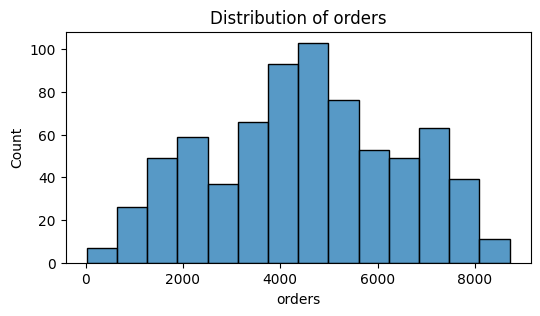

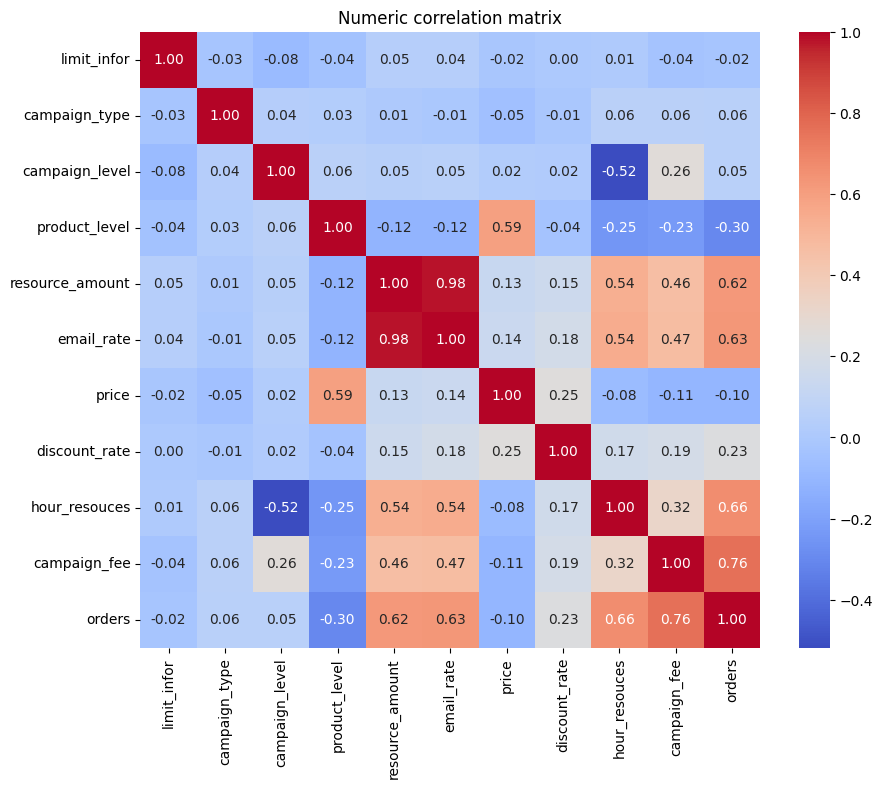

In [93]:

if not df.empty:
    targets = [c for c in ['orders','sales'] if c in df.columns]
    for t in targets:
        plt.figure(figsize=(6,3))
        sns.histplot(df[t].dropna(), kde=False)
        plt.title(f'Distribution of {t}')
        plt.show()

    numeric = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(10,8))
    sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Numeric correlation matrix")
    plt.show()
else:
    print("No data to plot.")


In [82]:
import numpy as np
import pandas as pd


def preprocess(df):
    df = df.copy()


    for col in df.select_dtypes(include=[np.number]):
        df[col] = df[col].fillna(df[col].median())


    for col in df.select_dtypes(include=['object', 'category']):
        df[col] = df[col].fillna('Missing')


    if {'price', 'discount_rate'}.issubset(df.columns):
        df['EffectivePrice'] = df['price'] * (1 - df['discount_rate'])

    if {'resource_amount', 'hour_resources'}.issubset(df.columns):
        df['BudgetPerHour'] = df['resource_amount'] / df['hour_resources'].replace(0, np.nan).fillna(1)

    return df

# preprocessing
if not df.empty:
    df_proc = preprocess(df)
    print(" Preprocessing done!")
    display(df_proc.head())
else:
    print(" No data to preprocess.")


 Preprocessing done!


,limit_infor,campaign_type,campaign_level,product_level,resource_amount,email_rate,price,discount_rate,hour_resouces,campaign_fee,orders,EffectivePrice
0,0,6,0,1,1,0.08,140.0,0.83,93,888,1981,23.80
1,0,0,0,1,1,0.10,144.0,0.75,150,836,986,36.00
2,0,1,1,1,1,0.12,149.0,0.84,86,1330,1416,23.84
3,0,3,1,2,1,0.12,141.0,0.82,95,2273,2368,25.38
4,0,0,0,1,1,0.10,146.0,0.59,73,1456,1529,59.86


In [83]:
if not df.empty:
    target = next((col for col in ['orders', 'sales'] if col in df.columns), None)
    if not target:
        raise ValueError("No 'orders' or 'sales' column found.")

    # Apply preprocessing to the features before creating X_enc
    df_processed_features = preprocess(df.drop(columns=[target]))

    drop_cols = ['id', 'campaign_id', 'date', 'start_date', 'end_date']
    X = df_processed_features.drop(columns=[c for c in drop_cols if c in df_processed_features.columns])
    y = df[target]

    X_enc = pd.get_dummies(X, drop_first=True)
    print(f" Target: {target} | Features: {X_enc.shape[1]}")
else:
    print("No data.")

 Target: orders | Features: 11


In [84]:
# Training set score
train_score = rf.score(X_train, y_train)

# Test set score
test_score = rf.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.993896048160252
Test Score: 0.9353239239451516


,0
campaign_fee,0.870205
hour_resouces,0.116910
email_rate,0.003992
price,0.003143
EffectivePrice,0.001983
campaign_type,0.001143
resource_amount,0.001052
discount_rate,0.000981
campaign_level,0.000349
product_level,0.000205


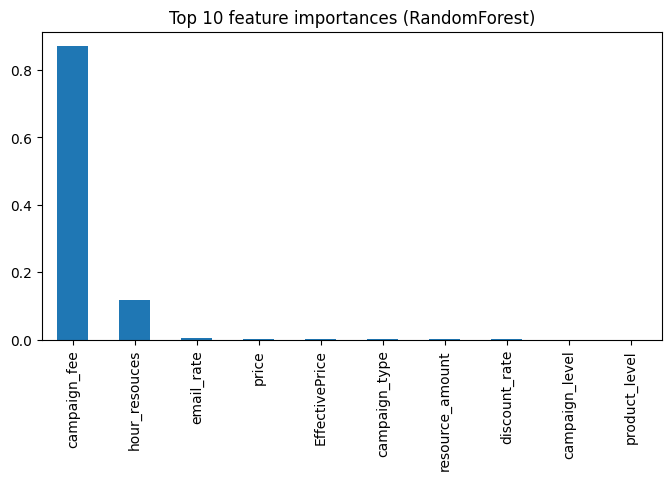

In [85]:

if not df.empty:
    importances = pd.Series(rf.feature_importances_, index=X_enc.columns)
    top10 = importances.sort_values(ascending=False).head(10)
    display(top10)
    plt.figure(figsize=(8,4))
    top10.plot(kind='bar')
    plt.title("Top 10 feature importances (RandomForest)")
    plt.show()
else:
    print("No feature importances.")


In [86]:

if not df.empty:
    model_path = '/content/baseline_rf_model.pkl'
    joblib.dump(rf, model_path)
    print("Saved model to", model_path)
else:
    print("No model to save.")

Saved model to /content/baseline_rf_model.pkl


In [87]:

print("Next steps: try LightGBM, Optuna tuning, SHAP explainability, temporal CV, and build predict API.")


Next steps: try LightGBM, Optuna tuning, SHAP explainability, temporal CV, and build predict API.


In [88]:

# LightGBM + Optuna Tuning
!pip install lightgbm optuna --quiet
from lightgbm import LGBMRegressor
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib # Import joblib

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds)**0.5
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(" Best Parameters:")
print(study.best_params)

# Build tuned model
best_params = study.best_params
best_lgb = LGBMRegressor(**best_params, random_state=42)
best_lgb.fit(X_train, y_train)
preds_lgb = best_lgb.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, preds_lgb)
rmse = mean_squared_error(y_test, preds_lgb)**0.5 # Calculate RMSE manually
r2 = r2_score(y_test, preds_lgb)
print(f"\nLightGBM Tuned → MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

# Save the best LightGBM model
model_path_lgb = '/content/best_lgb.pkl'
joblib.dump(best_lgb, model_path_lgb)
print(f"Saved tuned LightGBM model to {model_path_lgb}")

[I 2025-11-05 13:31:26,027] A new study created in memory with name: no-name-43932b7a-1c1f-4d5b-8af6-943b2adf85ad


  0%|          | 0/25 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [89]:
# predict_campaign_simple_lgbm.py

import joblib
import pandas as pd

sample_input = {
    "limit_infor": 0,
    "campaign_type": 6,
    "campaign_level": 0,
    "product_level": 1,
    "resource_amount": 1,
    "email_rate": 0.08,
    "price": 140.0,
    "discount_rate": 0.83,
    "hour_resouces": 93,
    "campaign_fee": 888
}

try:
    model = joblib.load("best_lgb.pkl")
    print(" LightGBM model loaded successfully.")
except FileNotFoundError:
    print(" Model file not found. Please ensure 'best_lgb.pkl' exists.")
    model = None


if model:
    # Convert sample_input to a DataFrame
    input_df = pd.DataFrame([sample_input])

    # Fill missing numeric values with median (using median from the training data if available, otherwise a default)
    # For this simple example, we'll use the median from the original df if available
    if 'price' in input_df.columns:
        # Check if 'df' exists and has a 'price' column before calculating median
        if 'df' in globals() and 'price' in df.columns:
            input_df['price'] = input_df['price'].fillna(df['price'].median())
        else:
            # Use a default median if original df not available
            input_df['price'] = input_df['price'].fillna(163.0)


    # Create the 'EffectivePrice' feature if price and discount_rate exist
    if {'price', 'discount_rate'}.issubset(input_df.columns):
         input_df['EffectivePrice'] = input_df['price'] * (1 - input_df['discount_rate'])
    else:

         input_df['EffectivePrice'] = 0


    # Add 'BudgetPerHour' feature (handle division by zero)
    if {'resource_amount', 'hour_resouces'}.issubset(input_df.columns):
        # Replace 0 with 1 to avoid division by zero, then calculate BudgetPerHour
        input_df['BudgetPerHour'] = input_df['resource_amount'] / input_df['hour_resouces'].replace(0, 1)


    if 'X_enc' in globals():
        for col in X_enc.columns:
            if col not in input_df.columns:
                input_df[col] = 0


        input_df = input_df[X_enc.columns]
    else:
        print("Error: X_enc (training data columns) not found. Cannot ensure correct feature order.")
        input_df = None


    if input_df is not None:

        pred = model.predict(input_df)[0]
        print(" Predicted Orders:", round(pred, 2))

 LightGBM model loaded successfully.
 Predicted Orders: 1315.47


In [90]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_enc, y, cv=5, scoring='neg_root_mean_squared_error')
print("CV RMSE (5-fold):", -scores.mean())


CV RMSE (5-fold): 422.124292685585


 RandomForest Regression Model Evaluation:
MAE  = 172.870
RMSE = 493.787
R2   = 0.935


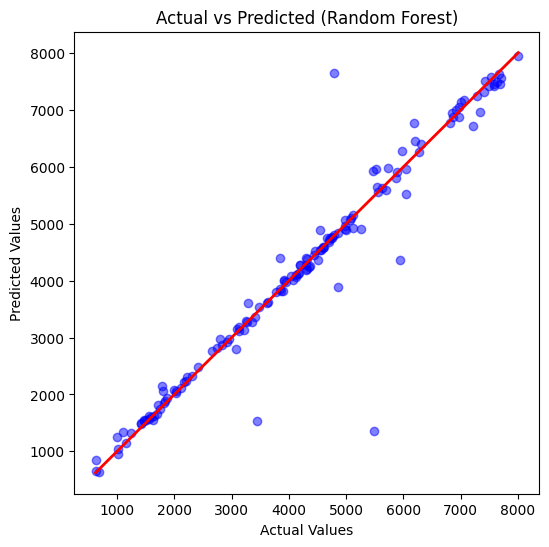

🧾 Predicted Orders: 6871.22


In [91]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f" RandomForest Regression Model Evaluation:")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R2   = {r2:.3f}")

# Step 5: Actual vs Predicted visualization
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

print("🧾 Predicted Orders:", round(y_pred[0], 2)) # Assuming you want to print the first prediction as an example
